In [1]:
import pandas as pd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point
import xarray as xr
import numpy as np
from rasterio.features import geometry_mask
from shapely.geometry import box
from itertools import product
import rioxarray
from math import pi, cos, radians

In [2]:
# Specify the path to your raster file (replace 'your_file.tif' with the actual file path)
file_path = '/home/madhulika.gurazada/paper2/Data/Global_cropland_3km_2019.tif'

# Open the raster file
with rasterio.open(file_path) as src:
    # Read raster data as a NumPy array
    croplands = src.read(1)  # Use `read(1)` for a single-band raster, adjust the band number if needed

    # Get metadata information
    metadata = src.meta

In [3]:
croplands

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [4]:
metadata

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 14000,
 'height': 5200,
 'count': 1,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.025000000000000053, 0.0, -170.0,
        0.0, -0.025000000000000053, 70.0)}

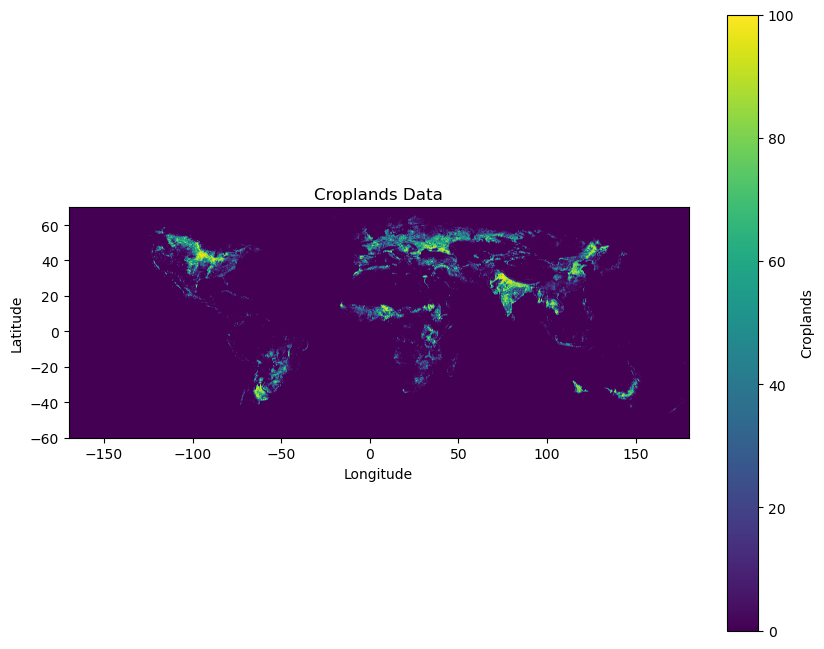

In [5]:
# Plot the croplands data
plt.figure(figsize=(10, 8))
plt.imshow(croplands, cmap='viridis', extent=[metadata['transform'][2], metadata['transform'][2] + metadata['width'] * metadata['transform'][0],
                                                  metadata['transform'][5] + metadata['height'] * metadata['transform'][4], metadata['transform'][5]])
plt.colorbar(label='Croplands')
plt.title('Croplands Data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

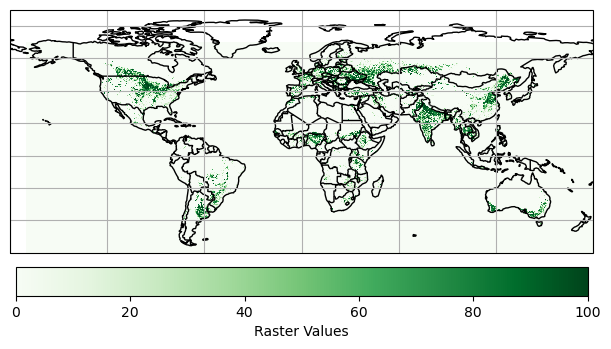

In [6]:
# Calculate aspect ratio
aspect_ratio = metadata['width'] / metadata['height']

# Set the figure size based on the aspect ratio
fig, ax = plt.subplots(figsize=(10, 10 / aspect_ratio), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the raster data with the correct extent and crs, using the reversed Greens colormap
c = ax.imshow(croplands, extent=[metadata['transform'][2], metadata['transform'][2] + metadata['width'] * metadata['transform'][0],
                                 metadata['transform'][5] + metadata['height'] * metadata['transform'][4], metadata['transform'][5]],
              origin='upper', cmap='Greens', interpolation='nearest', transform=ccrs.PlateCarree())

# Invert the y-axis to correct the plot
ax.invert_yaxis()

countries = cfeature.BORDERS
ax.add_feature(countries, linewidth=1, edgecolor='black')

# Add coastlines and gridlines
ax.set_extent([-182, 180, -60, 90], ccrs.PlateCarree())
ax.coastlines(linewidth=1, color='black')
ax.gridlines()

# Add colorbar
cbar = plt.colorbar(c, ax=ax, orientation='horizontal', fraction=0.1, pad=0.05)
cbar.set_label('Raster Values')

# Show the plot
plt.show()

In [7]:
# Specify the paths to your files
cru_path = '/home/madhulika.gurazada/paper2/Data/cru_ts4.06.1901.2021.pre.dat.nc'
croplands_path = '/home/madhulika.gurazada/paper2/Data/Global_cropland_3km_2019.tif'

# Open the CRU NetCDF file using xarray
cru = xr.open_dataset(cru_path)

# Open the croplands GeoTIFF file using rasterio
croplands = rasterio.open(croplands_path)

In [8]:
# Print the resolution of cru data
lat_resolution = cru['lat'].diff('lat').values[0]
lon_resolution = cru['lon'].diff('lon').values[0]

print(f"Latitude resolution: {lat_resolution} degrees")
print(f"Longitude resolution: {lon_resolution} degrees")

Latitude resolution: 0.5 degrees
Longitude resolution: 0.5 degrees


In [9]:
# Print the number of grid cells in cru
num_lat_cells = len(cru['lat'])
num_lon_cells = len(cru['lon'])

print(f"Number of latitude grid cells: {num_lat_cells}")
print(f"Number of longitude grid cells: {num_lon_cells}")
print(f"Total number of grid cells: {num_lat_cells * num_lon_cells}")

Number of latitude grid cells: 360
Number of longitude grid cells: 720
Total number of grid cells: 259200


In [10]:
# Print the resolution of croplands data
croplands_resolution_x = croplands.transform[0]
croplands_resolution_y = croplands.transform[4]

print(f"Resolution of croplands data in X direction: {croplands_resolution_x} units")
print(f"Resolution of croplands data in Y direction: {croplands_resolution_y} units")

Resolution of croplands data in X direction: 0.025000000000000053 units
Resolution of croplands data in Y direction: -0.025000000000000053 units


In [11]:
# Print the number of grid cells in croplands data
num_grid_cells_x = croplands.width
num_grid_cells_y = croplands.height

print(f"Number of grid cells in croplands data (X direction): {num_grid_cells_x}")
print(f"Number of grid cells in croplands data (Y direction): {num_grid_cells_y}")
print(f"Total number of grid cells in croplands data: {num_grid_cells_x * num_grid_cells_y}")

Number of grid cells in croplands data (X direction): 14000
Number of grid cells in croplands data (Y direction): 5200
Total number of grid cells in croplands data: 72800000


In [12]:
# Commands on Kamiak
# module load hdf5/1.10.2 
# module load netcdf/4.6.1 
# module load cdo/1.9.8 
# module load proj/5.1.0
# module load gdal/2.3.1

# gdal_translate -of NetCDF Global_cropland_3km_2019.tif Global_cropland_3km_2019.nc
# cdo remapcon,cru_ts4.06.1901.2021.pre.dat.nc Global_cropland_3km_2019.nc Global_cropland_0p5degree_2019.nc

In [13]:
# Load the NetCDF file into an xarray Dataset or DataArray
cropland_0p5 = xr.open_dataset('/home/madhulika.gurazada/paper2/Data/Global_cropland_0p5degree_2019.nc')
cropland_0p5

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Data variables:
    Band1    (lat, lon) float32 ...
Attributes:
    CDI:                 Climate Data Interface version 1.9.8 (https://mpimet...
    Conventions:         CF-1.5
    history:             Wed Mar 06 15:48:49 2024: cdo remapcon,cru_ts4.06.19...
    GDAL_AREA_OR_POINT:  Area
    GDAL:                GDAL 2.3.1, released 2018/06/22
    CDO:                 Climate Data Operators version 1.9.8 (https://mpimet...

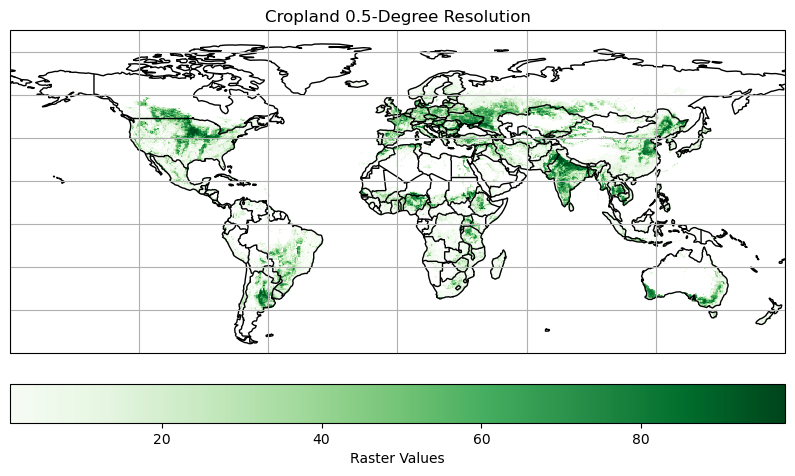

In [14]:
# Assuming cropland_0p5 is your xarray Dataset
# Extract the data variable you want to plot (replace 'variable_name' with the actual variable name)
variable_to_plot = cropland_0p5['Band1']

# Create a map projection using PlateCarree
projection = ccrs.PlateCarree()

# Create a figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(10, 8))

# Plot the data using pcolormesh
c = variable_to_plot.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='Greens', add_colorbar=False)

# Set the extent
ax.set_extent([-182, 180, -60, 90], ccrs.PlateCarree())
ax.coastlines(linewidth=1, color='black')
ax.gridlines()
countries = cfeature.BORDERS
ax.add_feature(countries, linewidth=1, edgecolor='black')

# Add a colorbar
cbar = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Raster Values')  # Replace 'Variable Units' with the actual units of your variable

# Set the title
plt.title('Cropland 0.5-Degree Resolution')

# Show the plot
plt.show()

In [15]:
# Assuming cropland_0p5 is your xarray DataArray
cropland_0p5_deg = cropland_0p5.to_dataframe().reset_index()

In [16]:
# Specify the path to your shapefile
shapefile_path = '/home/madhulika.gurazada/SREXRegions/IPCC-WGI-reference-regions-v4_shapefile/IPCC-WGI-reference-regions-v4.shp'

# Load the shapefile using geopandas
ipcc = gpd.read_file(shapefile_path)

# Define the values to remove ('Antarctica', 'Arctic', 'Pacific Islands region[2]', 'Pacific Islands region[3]')
values_to_remove = ['POLAR', 'ARCTIC', 'PACIFIC', 'ATLANTIC', 'INDIAN', 'SOUTHERN']

values_to_remove_1 = ['RAR']

filtered_ipcc = ipcc[~ipcc['Continent'].isin(values_to_remove) & ~ipcc['Acronym'].isin(values_to_remove_1)]

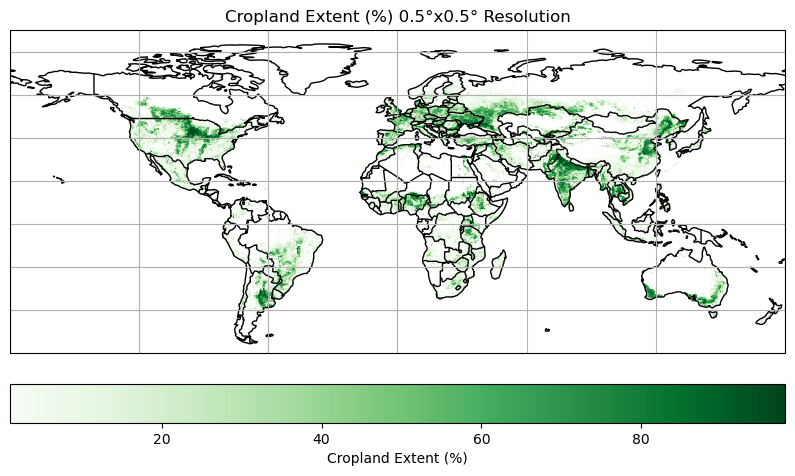

In [17]:
# Assuming cropland_0p5 is your xarray Dataset
# Extract the data variable you want to plot (replace 'variable_name' with the actual variable name)
variable_to_plot = cropland_0p5['Band1']

# Create a map projection using PlateCarree
projection = ccrs.PlateCarree()

# Create a figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(10, 8))

# Plot the data using pcolormesh
c = variable_to_plot.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='Greens', add_colorbar=False)


# Set the extent
ax.set_extent([-182, 180, -60, 90], ccrs.PlateCarree())
ax.coastlines(linewidth=1, color='black')
ax.gridlines()
countries = cfeature.BORDERS
ax.add_feature(countries, linewidth=1, edgecolor='black')

# Add a colorbar
cbar = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Cropland Extent (%)')  # Replace 'Variable Units' with the actual units of your variable

# Set the title
plt.title('Cropland Extent (%) 0.5°x0.5° Resolution')

# Show the plot
plt.show()

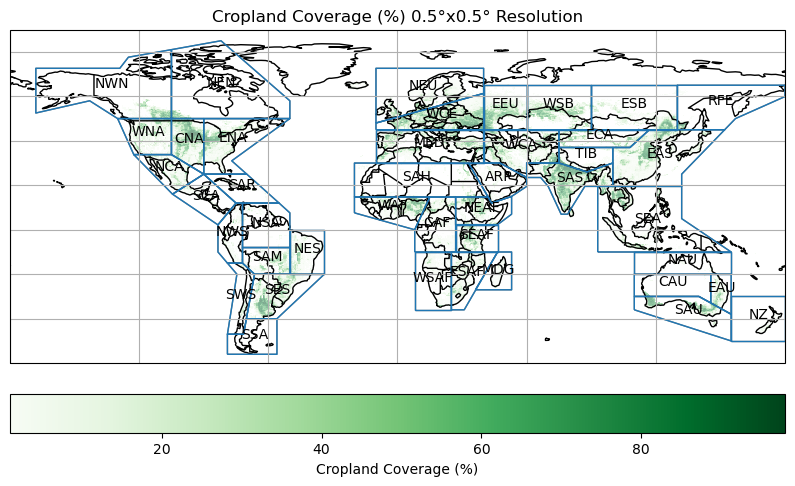

In [18]:
# Assuming cropland_0p5 is your xarray Dataset
# Extract the data variable you want to plot (replace 'variable_name' with the actual variable name)
variable_to_plot = cropland_0p5['Band1']

# Create a map projection using PlateCarree
projection = ccrs.PlateCarree()

# Create a figure and axis
fig, ax = plt.subplots(subplot_kw={'projection': projection}, figsize=(10, 8))

# Plot the data using pcolormesh
c = variable_to_plot.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='Greens', add_colorbar=False)

# Add filtered_ipcc polygons on the map
filtered_ipcc.plot(ax=ax, color='white', edgecolor='black', alpha=0.5, transform=ccrs.PlateCarree())

# Plot the shapefile with acronyms
filtered_ipcc.boundary.plot(ax=ax, linewidth=1)  # Plot the boundaries without filling
filtered_ipcc.apply(lambda x: ax.text(x.geometry.centroid.x, x.geometry.centroid.y, x['Acronym'], fontsize=10, ha='center'), axis=1)

# Set the extent
ax.set_extent([-182, 180, -60, 90], ccrs.PlateCarree())
ax.coastlines(linewidth=1, color='black')
ax.gridlines()
countries = cfeature.BORDERS
ax.add_feature(countries, linewidth=1, edgecolor='black')

# Add a colorbar
cbar = plt.colorbar(c, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Cropland Coverage (%)')  # Replace 'Variable Units' with the actual units of your variable

# Set the title
plt.title('Cropland Coverage (%) 0.5°x0.5° Resolution')

# Show the plot
plt.show()

In [21]:
cropland_0p5.to_netcdf("/home/madhulika.gurazada/paper2/Code/corrected_code/Code_to_use/correct_code/cropland_0p5_data.nc")